Import Libraries

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
import os
import random
from pathlib import Path
import shutil

Get Background Images (BingImageCrawler)

In [ ]:
!pip install icrawler -q

from icrawler.builtin import BingImageCrawler
import logging

logging.getLogger('icrawler').setLevel(logging.ERROR)

def download_backgrounds(num_images=100):

    search_terms = [
        "nature landscape",
        "city street",
        "ocean beach",
        "forest trees",
        "desert sand",
        "mountain view",
        "grass field",
        "cloudy sky",
        "sunset horizon",
        "rural farm"
    ]

    output_dir = "backgrounds_raw"
    per_term = (num_images // len(search_terms)) + 5

    print(f"Downloading {num_images} background images")

    for term in search_terms:
        try:
            print(f"Searching: {term}")
            save_dir = os.path.join(output_dir, term.replace(" ", "_"))
            crawler = BingImageCrawler(
                storage={"root_dir": save_dir},
                feeder_threads=1,
                parser_threads=1,
                downloader_threads=4
            )
            crawler.crawl(
                keyword=term,
                max_num=per_term,
                min_size=(640, 640),
                file_idx_offset=0
            )
        except Exception as e:
            print(f"  Warning: Error, trying next image")

    total = sum(
        len([f for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png', '.webp'))])
        for _, _, files in os.walk(output_dir)
    )
    return output_dir

backgrounds_dir = download_backgrounds(100)

Searching: nature landscape


ERROR:downloader:Response status code 403, file https://static.vecteezy.com/system/resources/previews/032/271/397/non_2x/waterfall-sunset-flowers-mountains-landscape-landscape-nature-nature-nature-ai-generated-free-photo.jpg
ERROR:downloader:Response status code 403, file https://wallpapercrafter.com/desktop/166040-nature-waterfall-trees-landscape.jpg


Searching: city street


ERROR:downloader:Response status code 403, file https://static.vecteezy.com/system/resources/thumbnails/032/401/125/small_2x/sidewalk-at-night-after-rain-with-wet-streets-ai-generative-free-photo.jpg
ERROR:downloader:Response status code 403, file https://static.vecteezy.com/system/resources/thumbnails/037/998/091/small_2x/ai-generated-night-city-landscape-with-street-lights-and-electric-wires-in-the-foreground-photo.jpg
ERROR:downloader:Response status code 403, file https://wallpapercrafter.com/desktop7/1719253-city-town-light-cityscape-urban-city-urban-street.jpg
ERROR:downloader:Response status code 403, file https://rare-gallery.com/uploads/posts/1055548-sunset-city-cityscape-water-reflection-sky-clouds-sunrise-skyline-skyscraper-evening-morning-New-York-City-horizon-dusk-metropolis-Roosevelt-Island-downtown-dawn-urban-.jpg
ERROR:downloader:Response status code 403, file https://static.vecteezy.com/system/resources/previews/020/043/151/original/night-urban-landscape-street-view-wi

Searching: ocean beach


...

Searching: cloudy sky


ERROR:downloader:Response status code 403, file https://images.wallpapersden.com/image/download/colored-cloudy-sky_bW5pamqUmZqaraWkpJRobWllrWdqa2U.jpg


Searching: sunset horizon


ERROR:downloader:Response status code 403, file https://images.wallpapersden.com/image/download/sunset-horizon-sky_ZmlpaGiUmZqaraWkpJRpbmdtrWhna2k.jpg
ERROR:downloader:Response status code 403, file https://images.wallpapersden.com/image/download/sea-sunset-horizon_14327_4240x2832.jpg
ERROR:downloader:Response status code 403, file https://images.wallpapersden.com/image/download/sunset-horizon_a2hrbWuUmZqaraWkpJRmbmdlrWZlbWU.jpg
ERROR:downloader:Response status code 403, file https://images.wallpapersden.com/image/download/sunset-horizon-hd-landscape_bmdnZWeUmZqaraWkpJRmbmdsrWZlbWU.jpg
ERROR:downloader:Response status code 403, file https://wallpapercrafter.com/desktop2/794209-nature-pictures-for-pc-1920x1200-sunset-water-sea.jpg
ERROR:downloader:Response status code 403, file https://rare-gallery.com/mocahbig/1384416-Sunset-Beach-Sea-Scenery-Horizon.jpg
ERROR:downloader:Response status code 403, file https://images.wallpapersden.com/image/download/horizon-sunset-in-ocean_a2dsbmyUmZqar

Searching: rural farm


Upload ROI Objects

In [ ]:
print("Please upload .zip with ROI object images")
uploaded = files.upload()

if uploaded:
    zip_filename = list(uploaded.keys())[0]

    import zipfile
    roi_dir = "roi_objects"
    os.makedirs(roi_dir, exist_ok=True)

    with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
        zip_ref.extractall(roi_dir)

    roi_files = []
    for root, dirs, files_list in os.walk(roi_dir):
        for file in files_list:
            if file.lower().endswith('.png') and '_ROI_' in file:
                roi_files.append(os.path.join(root, file))

Please upload .zip with ROI object images


Saving spelunky_ROI_results.zip to spelunky_ROI_results.zip


Resize Backgrounds

Resizing backgrounds to 640x640
Image resizing complete


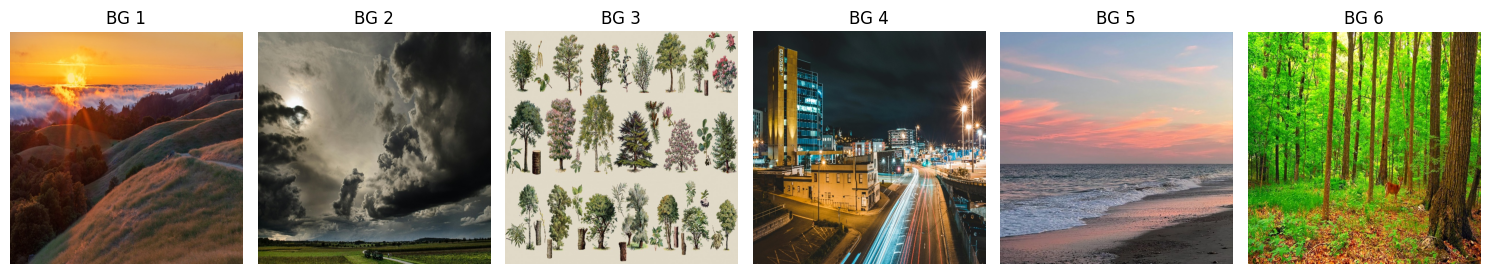

In [ ]:
def collect_and_resize_backgrounds(source_dir, target_size=640, num_images=100):

    output_dir = "backgrounds_640x640"
    os.makedirs(output_dir, exist_ok=True)

    image_extensions = ['.jpg', '.jpeg', '.png', '.bmp', '.webp']
    background_files = []

    for root, dirs, files_list in os.walk(source_dir):
        for file in files_list:
            if any(file.lower().endswith(ext) for ext in image_extensions):
                background_files.append(os.path.join(root, file))

    if len(background_files) > num_images:
        background_files = random.sample(background_files, num_images)

    resized_backgrounds = []

    print(f"Resizing backgrounds to {target_size}x{target_size}")

    for i, img_path in enumerate(background_files):
        try:
            img = cv2.imread(img_path)

            if img is None:
                continue

            resized = cv2.resize(img, (target_size, target_size))

            output_path = os.path.join(output_dir, f"background_{i:03d}.jpg")
            cv2.imwrite(output_path, resized)
            resized_backgrounds.append(output_path)

        except Exception as e:
            print(f"  Warning: Failed to process {img_path}: {e}")

    print(f"Image resizing complete")

    if len(resized_backgrounds) > 0:
        num_display = min(6, len(resized_backgrounds))
        fig, axes = plt.subplots(1, num_display, figsize=(15, 3))
        if num_display == 1:
            axes = [axes]

        for i in range(num_display):
            img = cv2.imread(resized_backgrounds[i])
            axes[i].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            axes[i].set_title(f'BG {i+1}')
            axes[i].axis('off')

        plt.tight_layout()
        plt.show()

    return resized_backgrounds

backgrounds = collect_and_resize_backgrounds('backgrounds_raw', target_size=640, num_images=100)

Generate Dataset

In [ ]:
def remove_white_background(roi_img, threshold=240):

    gray = cv2.cvtColor(roi_img, cv2.COLOR_BGR2GRAY)
    _, mask = cv2.threshold(gray, threshold, 255, cv2.THRESH_BINARY_INV)
    b, g, r = cv2.split(roi_img)
    bgra = cv2.merge([b, g, r, mask])

    return bgra

def paste_object_on_background(background, obj_bgra, x, y):

    bg_h, bg_w = background.shape[:2]
    obj_h, obj_w = obj_bgra.shape[:2]

    x = max(0, min(x, bg_w - 1))
    y = max(0, min(y, bg_h - 1))

    x2 = min(x + obj_w, bg_w)
    y2 = min(y + obj_h, bg_h)

    actual_w = x2 - x
    actual_h = y2 - y

    if actual_w <= 0 or actual_h <= 0:
        return background, None

    obj_crop = obj_bgra[:actual_h, :actual_w]
    alpha = obj_crop[:, :, 3] / 255.0
    bg_region = background[y:y2, x:x2]


    for c in range(3):
        bg_region[:, :, c] = (alpha * obj_crop[:, :, c] +
                              (1 - alpha) * bg_region[:, :, c])

    background[y:y2, x:x2] = bg_region

    return background, (x, y, actual_w, actual_h)

def generate_dataset(backgrounds, roi_files, num_images=200, objects_per_image=3, output_dir="yolo_dataset", image_size=640):

    images_dir = os.path.join(output_dir, "images")
    labels_dir = os.path.join(output_dir, "labels")
    os.makedirs(images_dir, exist_ok=True)
    os.makedirs(labels_dir, exist_ok=True)

    print(f"Generating {num_images} images")

    roi_objects = []
    for roi_path in roi_files:
        roi_img = cv2.imread(roi_path)
        roi_transparent = remove_white_background(roi_img, threshold=240)
        roi_objects.append(roi_transparent)

    generated_count = 0

    for i in range(num_images):
        bg_path = random.choice(backgrounds)
        background = cv2.imread(bg_path).copy()

        annotations = []

        num_objects = random.randint(objects_per_image - 1, objects_per_image + 1)
        num_objects = max(1, min(num_objects, len(roi_objects)))

        selected_objects = random.sample(roi_objects, num_objects)

        for obj_bgra in selected_objects:
            obj_h, obj_w = obj_bgra.shape[:2]

            max_x = max(0, image_size - obj_w)
            max_y = max(0, image_size - obj_h)

            x = random.randint(0, max_x) if max_x > 0 else 0
            y = random.randint(0, max_y) if max_y > 0 else 0

            background, bbox = paste_object_on_background(background, obj_bgra, x, y)

            if bbox is not None:
                bbox_x, bbox_y, bbox_w, bbox_h = bbox

                center_x = (bbox_x + bbox_w / 2) / image_size
                center_y = (bbox_y + bbox_h / 2) / image_size
                width_norm = bbox_w / image_size
                height_norm = bbox_h / image_size

                class_id = 0

                annotations.append(f"{class_id} {center_x:.6f} {center_y:.6f} {width_norm:.6f} {height_norm:.6f}")

        image_filename = f"image_{i:04d}.jpg"
        image_path = os.path.join(images_dir, image_filename)
        cv2.imwrite(image_path, background)

        label_filename = f"image_{i:04d}.txt"
        label_path = os.path.join(labels_dir, label_filename)

        with open(label_path, 'w') as f:
            for annotation in annotations:
                f.write(annotation + '\n')

        generated_count += 1

    print(f"Image generation complete, {generated_count} images generated")
    return output_dir

dataset_dir = generate_dataset(backgrounds=backgrounds, roi_files=roi_files, num_images=200, objects_per_image=3, output_dir="yolo_dataset", image_size=640)

Generating 200 images
Image generation complete


Visualization Example

In [ ]:
def visualize_yolo_annotations(image_path, label_path, image_size=640):

    img = cv2.imread(image_path)
    img_display = img.copy()

    with open(label_path, 'r') as f:
        annotations = f.readlines()

    for annotation in annotations:
        parts = annotation.strip().split()
        class_id = int(parts[0])
        center_x = float(parts[1]) * image_size
        center_y = float(parts[2]) * image_size
        width = float(parts[3]) * image_size
        height = float(parts[4]) * image_size

        x1 = int(center_x - width / 2)
        y1 = int(center_y - height / 2)
        x2 = int(center_x + width / 2)
        y2 = int(center_y + height / 2)

        cv2.rectangle(img_display, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.circle(img_display, (int(center_x), int(center_y)), 3, (0, 0, 255), -1)
        cv2.putText(img_display, f'Class {class_id}', (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

    return img_display

images_dir = os.path.join(dataset_dir, "images")
labels_dir = os.path.join(dataset_dir, "labels")

image_files = sorted([f for f in os.listdir(images_dir) if f.endswith('.jpg')])
num_samples = min(6, len(image_files))

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

sample_images = random.sample(image_files, num_samples)

for i, img_filename in enumerate(sample_images):
    img_path = os.path.join(images_dir, img_filename)
    label_path = os.path.join(labels_dir, img_filename.replace('.jpg', '.txt'))

    img_with_boxes = visualize_yolo_annotations(img_path, label_path)

    axes[i].imshow(cv2.cvtColor(img_with_boxes, cv2.COLOR_BGR2RGB))
    axes[i].set_title(f'{img_filename}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

Create YOLO Config

In [ ]:
def create_yolo_config(dataset_dir, class_names=["object"]):

    classes_path = os.path.join(dataset_dir, "classes.txt")
    with open(classes_path, 'w') as f:
        for class_name in class_names:
            f.write(class_name + '\n')

    yaml_content = f"""path: {os.path.abspath(dataset_dir)}
train: images
val: images

nc: {len(class_names)}
names: {class_names}
"""

    yaml_path = os.path.join(dataset_dir, "dataset.yaml")
    with open(yaml_path, 'w') as f:
        f.write(yaml_content)


    labels_dir = os.path.join(dataset_dir, "labels")

create_yolo_config(dataset_dir, class_names=["sprite"])

In [ ]:
zip_filename = "yolo_synthetic_dataset"
shutil.make_archive(zip_filename, 'zip', dataset_dir)

print(f"Created {zip_filename}.zip")
files.download(f"{zip_filename}.zip")

Created yolo_synthetic_dataset.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>